## Import

In [2]:
from utils import *
from sklearn.model_selection import train_test_split

## Parameters

In [3]:
target_column = "AMZN"
input_days= 30
output_days= [1, 7, 14]
test_size=0.2
shuffle=True

## Load dataset

In [4]:
data = read_and_clean_data(file_path = "./dataset/portfolio_data.csv", drop_list = ["DPZ", "BTC", "NFLX"])

Loading the data...
Data shape: (1520, 2)
Null values: Date    0
AMZN    0
dtype: int64
Duplicate rows: 0
Converting Date column to datetime...
Load data completed.


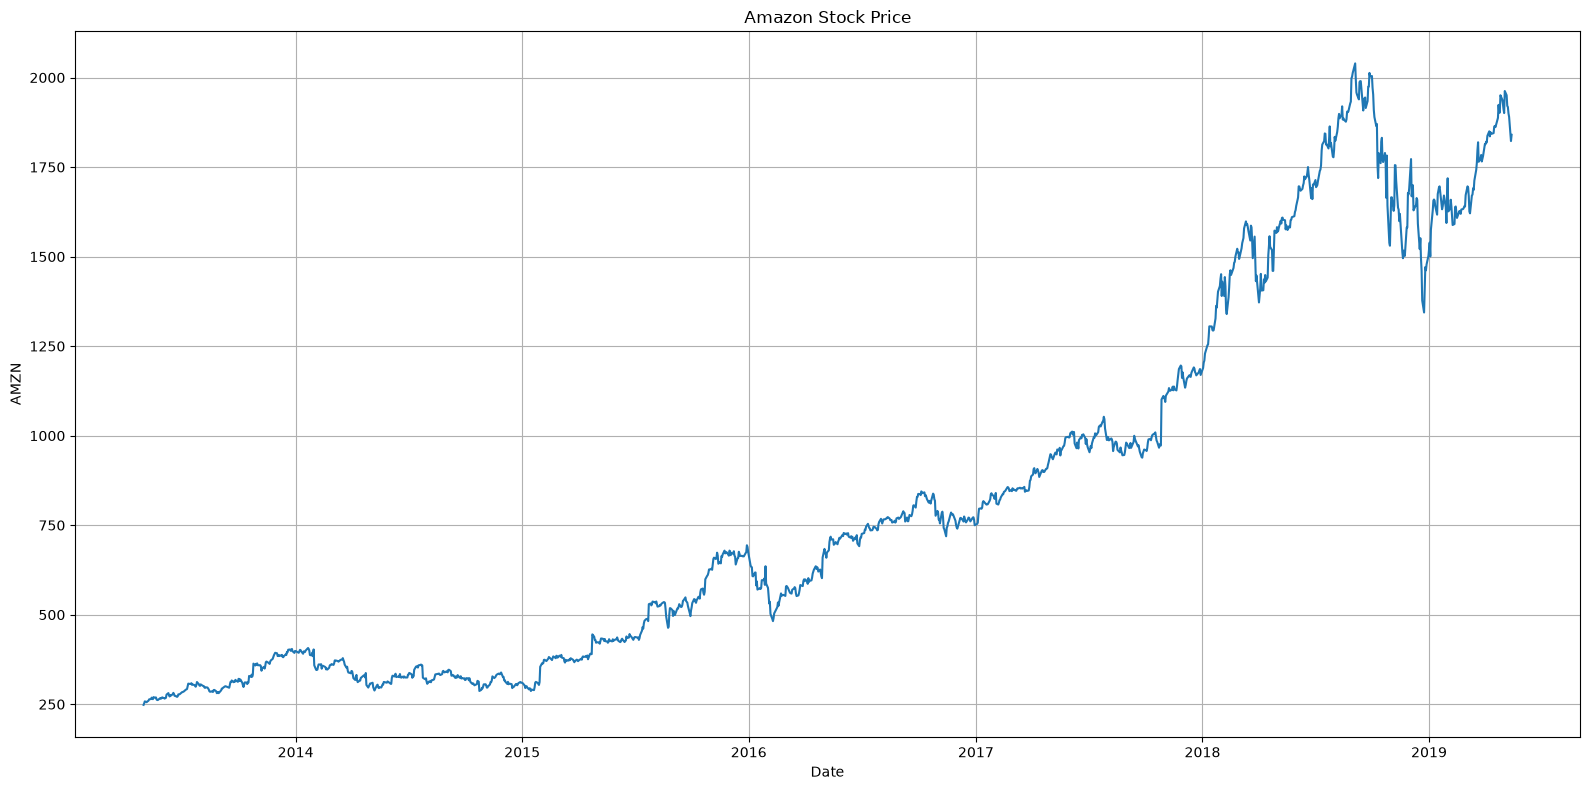

In [5]:
plot_data(data, "Amazon Stock Price", "Date", "AMZN")

### Generate Sliding Windows

In [6]:
selected_value = data[target_column].values
window_data = {}
for item in output_days:
    X, y = generate_sliding_windows(
        selected_value,
        input_days,
        item
        )
    window_data[item] = {
        "X" : X,
        "y" : y
    }

Input : 30 days | Output : 1 days | Windows: 1490
Input : 30 days | Output : 7 days | Windows: 1484
Input : 30 days | Output : 14 days | Windows: 1477


In [7]:
# window_output[1]["X"]

### Train / Test Split

In [8]:
train_test_data = {}

for day in output_days:
    X = window_data[day]["X"]
    y = window_data[day]["y"]

    X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size= test_size,
            shuffle= shuffle
        )
    train_test_data[day] = {
            "X_train" : X_train,
            "X_test" : X_test,
            "y_train" : y_train,
            "y_test" : y_test
            }

In [9]:
# print(train_test_data)
# print(train_test_data.keys)
# print(output_days)

### Data Scaling

In [10]:
scaled_data = {}
print("Start")
for day in train_test_data:
    
    X_train_norm, X_test_norm, y_train_norm, y_test_norm, target_scaler = scale_data(
        train_test_data[day]["X_train"],
        train_test_data[day]["X_test"],
        train_test_data[day]["y_train"],
        train_test_data[day]["y_test"]
    )
    print(f"day- {day}")
    print(f"X_train Shape: {X_train_norm.shape} - X_test Shape: {X_test_norm.shape}")
    print(f"y_train Shape: {y_train_norm.shape} - y_test Shape: {y_test_norm.shape}")

    scaled_data[day] = {
        "X_train_norm" : X_train_norm,
        "X_test_norm" : X_test_norm,
        "y_train_norm" : y_train_norm,
        "y_test_norm" : y_test_norm,
        "target_scaler" : target_scaler
        }
    # print(scaled_data[day]["X_train_norm"])
    # print(scaled_data[day]["y_train_norm"])

Start
day- 1
X_train Shape: (1192, 30) - X_test Shape: (298, 30)
y_train Shape: (1192, 1) - y_test Shape: (298, 1)
day- 7
X_train Shape: (1187, 30) - X_test Shape: (297, 30)
y_train Shape: (1187, 7) - y_test Shape: (297, 7)
day- 14
X_train Shape: (1181, 30) - X_test Shape: (296, 30)
y_train Shape: (1181, 14) - y_test Shape: (296, 14)


In [11]:
X_train.shape, y_train.shape

((1181, 30), (1181, 14))

In [12]:
1181/37

31.91891891891892

### Training Regression Models

#### Dense Deep Network

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def generate_model():
    dense_model = Sequential()

    # stock market => 30 days => input shape = 30
    # 10 days for input => input shape => 10
    # 100 days for input => input shape => 100
    # activation => sigmoid, tanh, relu, ...
    dense_model.add(Dense(8, input_shape=(30,), activation="relu"))
    dense_model.add(Dense(16, activation="relu"))
    dense_model.add(Dense(32, activation="relu"))
    dense_model.add(Dense(16, activation="relu"))
    dense_model.add(Dense(14))
    dense_model.summary()

    return dense_model

In [14]:
from tensorflow.keras.optimizers import Adam

dense_model1 = generate_model()
dense_model2 = generate_model()
dense_model3 = generate_model()

dense_model1.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001), metrics=['mean_absolute_error'])
dense_model2.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001), metrics=['mean_absolute_error'])
dense_model3.compile(loss='mean_absolute_error', optimizer=Adam(learning_rate=0.0001), metrics=['mean_absolute_error'])

e:\Python Git\ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 14)             │           238 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702 (6.65 KB)

 Trainable params: 1,702 (6.65 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 8)              │           248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 14)             │           238 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,702 (6.65 KB)

 Trainable params: 1,702 (6.65 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
hist1 = dense_model1.fit(
    X_train_norm, y_train_norm, 
    epochs=1000,
    validation_data=(X_test_norm, y_test_norm),
    verbose=1,
    batch_size=1
)

Epoch 1/1000
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.1780 - mean_absolute_error: 0.1780 - val_loss: 0.0864 - val_mean_absolute_error: 0.0864
Epoch 2/1000
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0674 - mean_absolute_error: 0.0674 - val_loss: 0.0438 - val_mean_absolute_error: 0.0438
Epoch 3/1000
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0345 - mean_absolute_error: 0.0345 - val_loss: 0.0272 - val_mean_absolute_error: 0.0272
Epoch 4/1000
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0259 - mean_absolute_error: 0.0259 - val_loss: 0.0237 - val_mean_absolute_error: 0.0237
Epoch 5/1000
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0241 - mean_absolute_error: 0.0241 - val_loss: 0.0229 - val_mean_absolute_error: 0.0229
Epoch 6/1000
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0232 - mean_absolute_error: 0.0232 - val_loss: 0.0229 - val_mean_absolute_error: 0.0229
Epoch 7/1000
1181/1181 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0229 - mea

In [16]:
hist2 = dense_model2.fit(
    X_train_norm, y_train_norm, 
    epochs=1000,
    validation_data=(X_test_norm, y_test_norm),
    verbose=1,
    batch_size=32
)

Epoch 1/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.3097 - mean_absolute_error: 0.3097 - val_loss: 0.2884 - val_mean_absolute_error: 0.2884
Epoch 2/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2927 - mean_absolute_error: 0.2927 - val_loss: 0.2707 - val_mean_absolute_error: 0.2707
Epoch 3/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2726 - mean_absolute_error: 0.2726 - val_loss: 0.2490 - val_mean_absolute_error: 0.2490
Epoch 4/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2479 - mean_absolute_error: 0.2479 - val_loss: 0.2225 - val_mean_absolute_error: 0.2225
Epoch 5/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2173 - mean_absolute_error: 0.2173 - val_loss: 0.1914 - val_mean_absolute_error: 0.1914
Epoch 6/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1875 - mean_absolute_error: 0.1875 - val_loss: 0.1676 - val_mean_absolute_error: 0.1676
Epoch 7/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1655 - mean_absolute_error: 0.1655 -

In [17]:
hist3 = dense_model3.fit(
    X_train_norm, y_train_norm, 
    epochs=1000,
    validation_data=(X_test_norm, y_test_norm),
    verbose=1,
    batch_size=512
)

Epoch 1/1000


3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - loss: 0.3157 - mean_absolute_error: 0.3157 - val_loss: 0.3011 - val_mean_absolute_error: 0.3011
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.3143 - mean_absolute_error: 0.3143 - val_loss: 0.2998 - val_mean_absolute_error: 0.2998
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.3129 - mean_absolute_error: 0.3129 - val_loss: 0.2984 - val_mean_absolute_error: 0.2984
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.3115 - mean_absolute_error: 0.3115 - val_loss: 0.2971 - val_mean_absolute_error: 0.2971
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.3101 - mean_absolute_error: 0.3101 - val_loss: 0.2957 - val_mean_absolute_error: 0.2957
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3087 - mean_absolute_error: 0.3087 - val_loss: 0.2942 - val_mean_absolute_error: 0.2942
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3072 - mean_absolute_error: 0.3072 - val_loss: 0.2928 - v

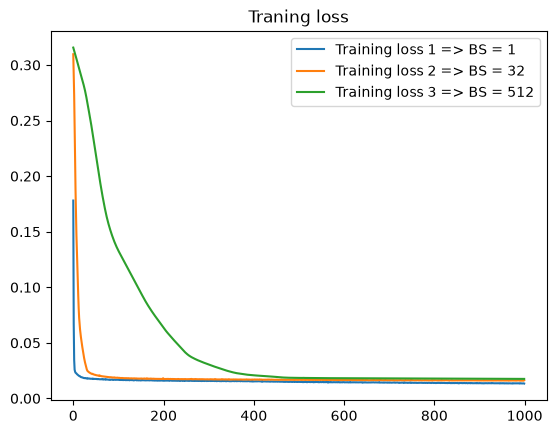

In [18]:
import matplotlib.pyplot as plt

plt.plot(hist1.history['loss'], label='Training loss 1 => BS = 1')
plt.plot(hist2.history['loss'], label='Training loss 2 => BS = 32')
plt.plot(hist3.history['loss'], label='Training loss 3 => BS = 512')
plt.title('Traning loss')
plt.legend()
plt.show()

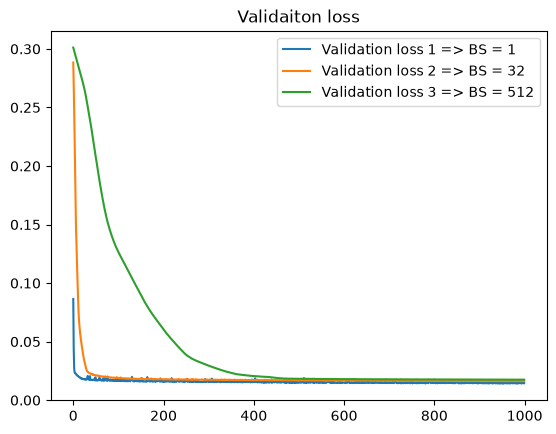

In [19]:
import matplotlib.pyplot as plt

plt.plot(hist1.history['val_loss'], label='Validation loss 1 => BS = 1')
plt.plot(hist2.history['val_loss'], label='Validation loss 2 => BS = 32')
plt.plot(hist3.history['val_loss'], label='Validation loss 3 => BS = 512')
plt.title('Validaiton loss')
plt.legend()
plt.show()

# Neuron

input => 1
Neuorn => 1

y = w * input + b

x (input) = 0.2
w = 0.9
b = 0.5
y = 0.2 * 0.9 + 0.5 = 0.68

if no activation has been selected => output = 0.68

if we activation => output = f(y) => 0 or 1


# 2 layers each with one neuron
y1 = x1 * w1 + b1 => as input of second layer
if no activation has been selected
y2 = y1 * w2 + b2 = (x1 * w1 + b1) * w2 + b2 = x1 * w1 * w2 + b1 * w2 + b2 = x1 * w2' + b2'
result => if even we add 100000 layers, it is similar to have only one!


if we have activation function
y1 = f(x1 * w1 + b1)
y2 = y1 * w2 + b2 =  f(x1 * w1 + b1) * w2 + b2